# Front tracking: four experiments ready to run

A Burgers pulse, merging shocks, a rarefaction and a nonconvex compound wave.


**Run all cells from top to bottom.** In Jupyter choose **Run → Run All Cells**;
in Colab choose **Runtime → Run all**. No account credentials, repository clone,
or file upload beyond this notebook is needed. Initial setup installs missing
NumPy, Matplotlib and ipywidgets. A CPU runtime is sufficient.

Each notebook carries a readable snapshot of the solver for standalone use.
Inside a local project checkout it uses `src/fronttrack` instead. Restart the
kernel/runtime after changing solver versions. GitHub displays saved figures;
open the notebook in Jupyter or Colab to use its controls.


In [1]:
# Install only missing dependencies into this notebook's Python environment.
import sys, subprocess, importlib.util
if sys.version_info < (3, 10):
    raise RuntimeError("Use Python 3.10 or newer")
requirements = {"numpy": "numpy>=1.24", "matplotlib": "matplotlib>=3.7",
                "ipywidgets": "ipywidgets>=8,<9"}
missing = [spec for name, spec in requirements.items() if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
if "google.colab" in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()
%matplotlib inline


In [2]:
# Standalone source snapshot. Generated by tools/build_notebooks.py; do not edit here.
from pathlib import Path
import tempfile, hashlib, json
BUNDLED_SOURCES = {'__init__.py': '"""Dafermos polygonal-flux front tracking for scalar conservation laws on R.\n\nPublic API (read the modules in this order):\n\n- ``DiscreteFlux``   (flux.py)          polygonal flux on a state grid\n- ``solve_riemann``  (riemann.py)       entropy envelope of one jump\n- ``Front``, ``FrontCollection``, ``initial_fronts`` (fronts.py)\n- ``next_interaction``, ``resolve_interaction``      (interactions.py)\n- ``FrontTracker``   (solver.py)        event-driven evolution driver\n\nInstall once with ``python -m pip install -e .`` from the repository root, or\nlet the repository\'s scripts add ``src/`` to the path themselves.\n"""\nfrom .flux import DiscreteFlux\nfrom .riemann import solve_riemann\nfrom .fronts import Front, FrontCollection, initial_fronts\nfrom .interactions import next_interaction, resolve_interaction\nfrom .solver import FrontTracker\n\n__version__ = "0.2.0"\n__all__ = [\n    "DiscreteFlux", "solve_riemann", "Front", "FrontCollection", "initial_fronts",\n    "next_interaction", "resolve_interaction", "FrontTracker",\n]\n', 'flux.py': '"""Approximate f(u) by the polygonal line through a fixed set of state nodes.\n\nPhysical states (for example u=0.5) and node indices (for example i=20) are\nseparate concepts: ``value``/``state_index`` take states, while ``rh``/``slope``\ntake indices. Fronts store indices so interaction states stay on this grid.\n"""\n\nimport operator\n\nimport numpy as np\n\n\nclass DiscreteFlux:\n    """Continuous piecewise linear flux on a strictly increasing state grid.\n\n    ``f`` must accept a NumPy array and return finite values of the same shape,\n    or a scalar for a constant flux. Nonuniform grids are supported. Arrays are\n    copied and made read-only so precomputed interval slopes remain consistent.\n    """\n\n    def __init__(self, f, u_grid):\n        # Validate once at construction; every Riemann solve reuses these nodes.\n        grid = np.array(u_grid, dtype=float, copy=True)\n        if grid.ndim != 1 or len(grid) < 2 or not np.all(np.isfinite(grid)):\n            raise ValueError("u_grid must contain at least two finite values")\n        if np.any(np.diff(grid) <= 0):\n            raise ValueError("u_grid must be strictly increasing")\n\n        values = np.asarray(f(grid), dtype=float)\n        if values.ndim == 0:\n            values = np.full_like(grid, values)\n        if values.shape != grid.shape or not np.all(np.isfinite(values)):\n            raise ValueError("f must return finite values matching u_grid")\n\n        self.f = f  # Keep the original callable for comparisons with f_h.\n        self.u_grid = grid\n        self.f_values = values.copy()\n        self._slopes = np.diff(self.f_values) / np.diff(grid)\n        for array in (self.u_grid, self.f_values, self._slopes):\n            array.flags.writeable = False\n\n    def validate_index(self, i) -> int:\n        """Accept Python/NumPy integers; reject fractional or out-of-range indices."""\n        i = operator.index(i)\n        if not 0 <= i < len(self.u_grid):\n            raise IndexError("State index out of bounds")\n        return i\n\n    def slope(self, i) -> float:\n        """Return the precomputed slope on [u_grid[i], u_grid[i+1]]."""\n        i = self.validate_index(i)\n        if i == len(self.u_grid) - 1:\n            raise IndexError("Slope index out of bounds")\n        return float(self._slopes[i])\n\n    def rh(self, iL, iR) -> float:\n        """Rankine–Hugoniot speed: flux difference divided by state difference."""\n        iL, iR = self.validate_index(iL), self.validate_index(iR)\n        if iL == iR:\n            raise ValueError("RH speed undefined for equal states")\n        return float(\n            (self.f_values[iR] - self.f_values[iL])\n            / (self.u_grid[iR] - self.u_grid[iL])\n        )\n\n    def _states(self, u):\n        """Normalize scalar/array input and reject extrapolation outside the grid."""\n        u = np.asarray(u, dtype=float)\n        if (not np.all(np.isfinite(u)) or np.any(u < self.u_grid[0])\n                or np.any(u > self.u_grid[-1])):\n            raise ValueError("State outside discretised flux range")\n        return u\n\n    def _interval_indices(self, u):\n        """Locate already validated states without repeating range checks."""\n        # side=\'right\' chooses the interval beginning at an interior node.\n        # At the final node there is no right interval, so use the last one.\n        return np.clip(\n            np.searchsorted(self.u_grid, u, side="right") - 1,\n            0, len(self.u_grid) - 2,\n        )\n\n    def interval_index(self, u):\n        """Right interval at an interior knot; last interval at the endpoint."""\n        u = self._states(u)\n        indices = self._interval_indices(u)\n        return int(indices) if u.ndim == 0 else indices\n\n    def value(self, u):\n        """Evaluate f_h, preserving array shape or returning a float for a scalar."""\n        u = self._states(u)\n        indices = self._interval_indices(u)\n        # Interpolation reuses slopes instead of dividing again for every query.\n        value = self.f_values[indices] + (u - self.u_grid[indices]) * self._slopes[indices]\n        return float(value) if u.ndim == 0 else value\n\n    def state_index(self, u):\n        """Quantize to the nearest node (ties choose the lower node). No clipping."""\n        u = self._states(u)\n        # Bracket each state, then compare distances to the two candidate nodes.\n        hi = np.clip(np.searchsorted(self.u_grid, u), 1, len(self.u_grid) - 1)\n        lo = hi - 1\n        indices = np.where(u - self.u_grid[lo] <= self.u_grid[hi] - u, lo, hi)\n        return int(indices) if u.ndim == 0 else indices\n', 'fronts.py': '"""Represent moving jumps and expand piecewise constant initial data into fronts.\n\nA single initial jump can generate several fronts (a rarefaction staircase),\none front (for example a shock), or none when its two states are equal.\n"""\n\nfrom dataclasses import dataclass\nfrom itertools import pairwise\nimport math\n\nimport numpy as np\n\nfrom .riemann import solve_riemann\n\n\n@dataclass(slots=True)\nclass Front:\n    """One moving discontinuity with a constant speed until its next collision.\n\n    ``x`` is its current position. ``iL``/``iR`` are flux-node indices on its\n    left/right. Slots reduce per-front memory; only position changes in flight.\n    """\n\n    x: float\n    iL: int\n    iR: int\n    speed: float\n\n\nclass FrontCollection:\n    """Spatially ordered fronts; ownership and collision handling live in the driver."""\n\n    def __init__(self, fronts):\n        self.fronts = list(fronts)\n\n    def advance(self, dt: float) -> None:\n        """Translate all fronts by speed * dt; caller must prevent crossings."""\n        if not math.isfinite(dt) or dt < 0:\n            raise ValueError("dt must be finite and nonnegative")\n        for front in self.fronts:\n            front.x += front.speed * dt\n\n\ndef initial_fronts(positions, states, flux) -> FrontCollection:\n    """Expand N strictly ordered jumps and N+1 integer state indices.\n\n    The first and last states extend to infinity. Multiple outgoing fronts from\n    one jump start at the same point, already ordered by their Riemann speeds.\n    """\n    positions = np.asarray(positions, dtype=float)\n    states = [flux.validate_index(i) for i in states]\n    if positions.ndim != 1 or len(states) != len(positions) + 1:\n        raise ValueError("Need N jump positions and N+1 state indices")\n    if not np.all(np.isfinite(positions)) or np.any(np.diff(positions) <= 0):\n        raise ValueError("Jump positions must be finite and strictly increasing")\n\n    # Keep the initial spatial order. Sorting by state or by speed globally\n    # would destroy the ordering of the piecewise constant solution.\n    fronts = []\n    for x, (iL, iR) in zip(positions, pairwise(states)):\n        for left, right, speed in solve_riemann(iL, iR, flux):\n            fronts.append(Front(float(x), left, right, speed))\n    return FrontCollection(fronts)\n', 'interactions.py': '"""Predict adjacent collisions and solve the Riemann problem they create.\n\nOnly neighbors need checking: a front cannot reach a non-neighbor without\nfirst meeting the front between them. Prediction remains a readable O(N) scan.\n"""\n\nfrom itertools import pairwise\nimport math\n\nfrom .fronts import Front, FrontCollection\nfrom .riemann import solve_riemann\n\n\ndef next_interaction(fronts) -> tuple[float, int | None]:\n    """Return (relative waiting time, left pair index), or (inf, None).\n\n    Accept either a front list or FrontCollection. Ties select the first pair;\n    the driver subsequently handles any other event at the same absolute time.\n    """\n    fronts = fronts.fronts if isinstance(fronts, FrontCollection) else fronts\n    best_time, index = math.inf, None\n    # pairwise iterates without allocating the full fronts[1:] list each event.\n    for i, (left, right) in enumerate(pairwise(fronts)):\n        closing_speed = left.speed - right.speed\n        if closing_speed > 0:\n            # Equal or separating speeds never collide, even at the same point.\n            # Clamp tiny negative gaps due to roundoff to an immediate event.\n            dt = max(0.0, (right.x - left.x) / closing_speed)\n            if dt < best_time:\n                best_time, index = dt, i\n    return best_time, index\n\n\ndef resolve_interaction(front_i, front_j, flux) -> list[Front]:\n    """Replace a collided cluster using only its two exterior states.\n\n    Caller advances incoming fronts to the collision point first. Arguments\n    may be the first and last fronts of a multiway cluster. Intermediate states\n    occupy zero width at the event and disappear from the new local problem.\n    """\n    x = 0.5 * (front_i.x + front_j.x)\n    return [Front(x, left, right, speed)\n            for left, right, speed in solve_riemann(front_i.iL, front_j.iR, flux)]\n', 'riemann.py': '"""Resolve one initial jump using an entropy envelope of the polygonal flux.\n\nAn increasing jump uses the lower convex envelope; a decreasing jump uses the\nupper concave envelope. Envelope edges become moving fronts. In both cases,\nthe returned fronts are ordered from left to right in physical space.\n"""\n\nimport math\nfrom itertools import pairwise\n\nfrom .flux import DiscreteFlux\n\n# Each wave stores node indices, followed by its physical propagation speed.\nWave = tuple[int, int, float]\n\n\ndef solve_riemann(iL, iR, flux: DiscreteFlux) -> list[Wave]:\n    """Return (left index, right index, RH speed) waves in spatial order.\n\n    The hull is a stack: each node is appended once and removed at most once,\n    giving O(abs(iR-iL)) work. A second stack stores accepted edge slopes so\n    unchanged edges do not need repeated Rankine–Hugoniot calculations.\n    """\n    iL, iR = flux.validate_index(iL), flux.validate_index(iR)\n    if iL == iR:\n        return []  # Identical states have no discontinuity.\n\n    convex = iL < iR\n    states, values = flux.u_grid, flux.f_values\n    hull: list[int] = []\n    slopes: list[float] = []  # slopes[j] joins hull[j] to hull[j+1].\n\n    # Always build in increasing STATE order; reverse for a downward jump later.\n    for node in range(min(iL, iR), max(iL, iR) + 1):\n        while hull:\n            previous = hull[-1]\n            # The endpoints were validated above and all visited nodes lie\n            # between them. Avoid re-validating indices inside this hot loop.\n            speed = float(\n                (values[node] - values[previous])\n                / (states[node] - states[previous])\n            )\n            if not slopes:\n                break\n            violates_envelope = slopes[-1] >= speed if convex else slopes[-1] <= speed\n            if not violates_envelope:\n                break\n            # The last node lies above the lower hull (or below the upper hull).\n            # Drop it and retry the chord from the preceding node to this node.\n            # Equality also removes collinear nodes, yielding a single contact.\n            hull.pop()\n            slopes.pop()\n        if hull:\n            slopes.append(speed)\n        hull.append(node)\n\n    # On an upper hull, slopes decrease in state order. Reversing both stacks\n    # gives increasing speeds in physical space and the requested iL -> iR jump.\n    if not convex:\n        hull.reverse()\n        slopes.reverse()\n    return [(a, b, speed) for (a, b), speed in zip(pairwise(hull), slopes)]\n\n\ndef wave_direction(iL, iR) -> int:\n    """Sign of the state jump (+1 increasing, -1 decreasing, 0 absent)."""\n    return int(iR > iL) - int(iR < iL)\n\n\ndef enforce_entropy(waves):\n    """Validate wave continuity and ordering; return the unchanged wave list.\n\n    Kept for compatibility. This does not construct or repair an entropy hull:\n    increasing speeds alone cannot establish admissibility for a nonconvex flux.\n    Use ``solve_riemann`` for the actual entropy construction.\n    """\n    for left, right in pairwise(waves):\n        if left[1] != right[0] or left[2] > right[2]:\n            raise ValueError("Waves must be connected with nondecreasing speeds")\n    if any(not math.isfinite(wave[2]) for wave in waves):\n        raise ValueError("Wave speeds must be finite")\n    return waves\n', 'solver.py': '"""Event-driven scalar front tracking on R with constant exterior states.\n\nThe evolving solution is represented entirely by ordered fronts and a left\nfar-field state. There is no spatial evolution mesh or CFL time step. Sampling\nand plotting grids observe the solution without changing its discretization.\n"""\n\nfrom dataclasses import replace\nimport math\n\nimport numpy as np\n\nfrom .fronts import initial_fronts\nfrom .interactions import next_interaction, resolve_interaction\n\n# Relative allowance for roundoff when identifying a multi-front collision.\n_ROUNDOFF_FACTOR = 16 * np.finfo(float).eps\n\n\nclass FrontTracker:\n    """Evolve node-valued step data by repeatedly solving local Riemann problems.\n\n    Supply N jump positions and N+1 integer state indices, or use ``from_values``\n    to quantize physical values. ``run(T)`` advances in place to absolute time T.\n    ``position_tol`` is in spatial units; nearby fronts at a triggered collision\n    are combined. ``max_events`` limits cumulative collision clusters.\n    """\n\n    def __init__(self, flux, positions, states, *, position_tol=1e-12,\n                 max_events=100000, record_history=True):\n        self.flux = flux\n        states = list(states)\n        self.collection = initial_fronts(positions, states, flux)\n        self.left_state, self.right_state = states[0], states[-1]\n        if not math.isfinite(position_tol) or position_tol < 0:\n            raise ValueError("position_tol must be finite and nonnegative")\n        if not isinstance(max_events, int) or max_events < 1:\n            raise ValueError("max_events must be a positive integer")\n        self.position_tol = position_tol\n        self.max_events = max_events\n        self.record_history = record_history\n        self.time = 0.0\n        self.event_count = 0\n        # Entries are (x_start, t_start, x_end, t_end), suitable for plotting.\n        # Disable recording for long runs when only final states are required.\n        self.segments = []\n\n    @classmethod\n    def from_values(cls, flux, positions, values, **kwargs):\n        """Map physical values to nearest flux nodes and initialize the tracker."""\n        return cls(flux, positions, flux.state_index(values), **kwargs)\n\n    @property\n    def fronts(self):\n        """Live spatially ordered front list. Use snapshot() for an editable copy."""\n        return self.collection.fronts\n\n    def _advance(self, dt: float) -> None:\n        """Advance by an internally validated increment, optionally recording paths."""\n        if dt == 0:\n            return  # Simultaneous events require no motion or history entries.\n        end_time = self.time + dt\n        if self.record_history:\n            # Record and translate in the same pass, calculating each endpoint\n            # once. This avoids the former second traversal of all fronts.\n            append = self.segments.append\n            for front in self.fronts:\n                end_x = front.x + front.speed * dt\n                append((front.x, self.time, end_x, end_time))\n                front.x = end_x\n        else:\n            self.collection.advance(dt)\n        self.time = end_time\n\n    def _resolve_cluster(self, pair_index: int) -> None:\n        """Replace the full cluster surrounding an already advanced colliding pair."""\n        fronts = self.fronts\n        x = 0.5 * (fronts[pair_index].x + fronts[pair_index + 1].x)\n        first, last = pair_index, pair_index + 1\n        tolerance = self.position_tol + _ROUNDOFF_FACTOR * max(1.0, abs(x))\n\n        # Compare every member to the event point, not just its neighbor, to\n        # avoid chaining many small gaps into an arbitrarily wide cluster.\n        while first > 0 and abs(fronts[first - 1].x - x) <= tolerance:\n            first -= 1\n        while last + 1 < len(fronts) and abs(fronts[last + 1].x - x) <= tolerance:\n            last += 1\n\n        outgoing = resolve_interaction(fronts[first], fronts[last], self.flux)\n        for front in outgoing:\n            front.x = x  # All waves in the new Riemann fan share one origin.\n        fronts[first:last + 1] = outgoing\n        self.event_count += 1\n\n    def run(self, final_time: float):\n        """Advance to absolute final_time, resolving events exactly at that time.\n\n        Returns self for chaining. Calling again continues the current solution;\n        going backward is rejected. An event-limit error leaves the state at\n        its last completed event so it can be inspected or resumed.\n        """\n        if not math.isfinite(final_time) or final_time < self.time:\n            raise ValueError("final_time must be finite and at least the current time")\n        while True:\n            dt, pair_index = next_interaction(self.fronts)\n            remaining = final_time - self.time\n            if pair_index is None or dt > remaining:\n                # No interaction before the observation time: pure translation.\n                self._advance(remaining)\n                self.time = float(final_time)\n                return self\n            if self.event_count >= self.max_events:\n                raise RuntimeError("Event limit reached; inspect data or raise max_events")\n\n            self._advance(dt)\n            self._resolve_cluster(pair_index)\n            # Re-scan because the replacement fronts have new neighbors/speeds.\n            # A separate simultaneous collision has dt=0 on the next iteration.\n\n    def snapshot(self):\n        """Independent copies of front geometry; this is not a full restart file."""\n        return [replace(front) for front in self.fronts]\n\n    def sample(self, x):\n        """Right-continuous point values, with the shape of x; no time advancement."""\n        x = np.asarray(x, dtype=float)\n        if not np.all(np.isfinite(x)):\n            raise ValueError("Sample coordinates must be finite")\n        positions = [front.x for front in self.fronts]\n        states = [self.left_state] + [front.iR for front in self.fronts]\n        # The insertion index counts jumps at or left of x. side=\'right\' also\n        # crosses every coincident initial front, selecting the outer right state.\n        indices = np.searchsorted(positions, x, side="right")\n        values = self.flux.u_grid[np.asarray(states)[indices]]\n        return float(values) if x.ndim == 0 else values\n\n    def integral(self, a: float, b: float) -> float:\n        """Integrate the step solution on [a,b] in one pass over its fronts.\n\n        Each region contributes width * state. No midpoint sampling, binary\n        searches, or quadrature grid is needed. Coincident fronts contribute\n        zero width and still update the state correctly.\n        """\n        if not math.isfinite(a) or not math.isfinite(b) or a >= b:\n            raise ValueError("Require finite a < b")\n\n        def contributions():\n            position, state = a, self.left_state\n            grid = self.flux.u_grid\n            for front in self.fronts:\n                if front.x <= a:\n                    state = front.iR  # Find the state at the left window edge.\n                    continue\n                if front.x >= b:\n                    break\n                yield (front.x - position) * grid[state]\n                position, state = front.x, front.iR\n            yield (b - position) * grid[state]\n\n        # fsum reduces cancellation for profiles with both positive and negative\n        # mass, without allocating an array of all interval contributions.\n        return math.fsum(contributions())\n\n    def total_variation(self) -> float:\n        """Sum absolute jump strengths, including jumps to exterior states."""\n        grid = self.flux.u_grid\n        return math.fsum(abs(grid[front.iR] - grid[front.iL]) for front in self.fronts)\n', 'visualization.py': '"""Optional Matplotlib/ipywidgets views; importing this module needs only NumPy.\n\nColours represent u, never a front index or speed. Time rasters are sampled\nobservations (nearest-frame display), not additional evolution discretizations.\n"""\nfrom dataclasses import dataclass, field\nimport numpy as np\n\n\ndef _axis(values, name, minimum=2):\n    a = np.array(values, dtype=float, copy=True)\n    if a.ndim != 1 or len(a) < minimum or not np.isfinite(a).all() or np.any(np.diff(a) <= 0):\n        raise ValueError(f\'{name} must contain at least {minimum} finite, strictly increasing values\')\n    return a\n\n\n@dataclass\nclass History:\n    """Observed 1D profiles. Exact step snapshots are optional (edges, values)."""\n    x: np.ndarray\n    times: np.ndarray\n    values: np.ndarray\n    segments: list = field(default_factory=list)\n    profiles: list = field(default_factory=list)\n    cell_edges: object = None\n    valid: object = None\n    coordinate_label: str = "x"\n\n    def __post_init__(self):\n        self.x = _axis(self.x, \'x\')\n        self.times = _axis(self.times, \'times\', 1)\n        self.values = np.array(self.values, dtype=float, copy=True)\n        if self.values.shape != (len(self.times), len(self.x)) or not np.isfinite(self.values).all():\n            raise ValueError(\'values must be finite with shape (len(times), len(x))\')\n\n\ndef step_profile(tracker, window):\n    """Exact jump locations in a window, including periodic chart seams."""\n    a, b = _axis(window, \'window\')\n    positions = np.array([f.x for f in tracker.fronts])\n    if hasattr(tracker, \'domain\'):\n        domain = tracker.domain\n        if a < domain.origin or b > domain.origin + domain.length:\n            raise ValueError(\'Use one periodic chart for exact profiles\')\n        positions = domain.wrap(positions)\n    edges = np.unique(np.r_[a, positions[(positions > a) & (positions < b)], b])\n    # Right-continuous samples at left edges avoid midpoint rounding at tiny cells.\n    return edges, np.asarray(tracker.sample(edges[:-1]))\n\n\ndef observe_tracker(tracker, x, times):\n    """Advance a real-line/circle tracker and retain exact snapshots and samples.\n\n    This consumes the tracker up to times[-1]; use a fresh tracker to start over.\n    All input validation precedes advancement. History recording is optional.\n    """\n    x, times = _axis(x, \'x\'), _axis(times, \'times\', 1)\n    if times[0] < tracker.time:\n        raise ValueError(\'Observation times precede the current tracker time\')\n    step_profile(tracker, (x[0], x[-1]))  # Validate chart limits before advancing.\n    profiles, values = [], []\n    for t in times:\n        tracker.run(float(t))\n        values.append(tracker.sample(x))\n        profiles.append(step_profile(tracker, (x[0], x[-1])))\n    return History(x, times, values, list(getattr(tracker, \'segments\', [])), profiles)\n\n\ndef color_norm(values, limits=None):\n    """A stable colour scale over the entire run, including constant solutions."""\n    from matplotlib.colors import Normalize\n    if isinstance(values, History):\n        samples = [values.values.ravel()]\n        samples.extend(np.asarray(v) for _, v in values.profiles)\n        values = np.concatenate(samples)\n    lo, hi = (float(np.min(values)), float(np.max(values))) if limits is None else limits\n    if not np.isfinite([lo, hi]).all() or lo > hi:\n        raise ValueError(\'Colour limits must be finite and ordered\')\n    if lo == hi:\n        pad = max(1, abs(lo)) * .01\n        lo, hi = lo - pad, hi + pad\n    return Normalize(lo, hi)\n\n\ndef plot_profile(history, index=-1, *, ax=None, cmap=\'viridis\', norm=None):\n    """Render a snapshot, using exact front positions when available."""\n    import matplotlib.pyplot as plt\n    from matplotlib.collections import LineCollection\n    ax = plt.subplots(figsize=(7, 3.5))[1] if ax is None else ax\n    norm = color_norm(history) if norm is None else norm\n    if history.profiles:\n        edges, values = history.profiles[index]\n    else:\n        edges, values = history.x, history.values[index, :-1]\n    ax.stairs(values, edges, color=\'0.25\', linewidth=.8)\n    lines = [[(a, u), (b, u)] for a, b, u in zip(edges[:-1], edges[1:], values)]\n    collection = LineCollection(lines, cmap=cmap, norm=norm, linewidths=2.5)\n    collection.set_array(np.asarray(values))\n    ax.add_collection(collection)\n    if history.valid is not None:\n        for a, b, ok in zip(edges[:-1], edges[1:], history.valid[index]):\n            if not ok:\n                ax.axvspan(a, b, facecolor=\'none\', edgecolor=\'0.5\', hatch=\'///\', linewidth=0)\n    pad = .08 * (norm.vmax - norm.vmin)\n    ax.set(xlim=(history.x[0], history.x[-1]), ylim=(norm.vmin-pad, norm.vmax+pad),\n           xlabel=history.coordinate_label, ylabel=\'u\', title=f\'Profile at t = {history.times[index]:g}\')\n    return ax\n\n\ndef _hatch_cells(ax, xedges, yedges, invalid):\n    """Hatch only the specified cells; keep masking independent of colour arrays."""\n    from matplotlib.collections import PolyCollection\n    rows, cols = np.nonzero(invalid)\n    quads = [[(xedges[j], yedges[i]), (xedges[j+1], yedges[i]),\n              (xedges[j+1], yedges[i+1]), (xedges[j], yedges[i+1])]\n             for i, j in zip(rows, cols)]\n    overlay = PolyCollection(quads, facecolors=\'none\', edgecolors=\'0.45\',\n                             linewidths=0, hatch=\'///\')\n    ax.add_collection(overlay)\n\n\ndef plot_spacetime(history, *, ax=None, cmap=\'viridis\', norm=None, fronts=True, colorbar=True):\n    """Sampled colour field with exact recorded front segments overlaid."""\n    import matplotlib.pyplot as plt\n    from matplotlib.collections import LineCollection\n    if len(history.times) < 2:\n        raise ValueError(\'Space–time rendering needs at least two distinct times\')\n    ax = plt.subplots(figsize=(7, 4.5))[1] if ax is None else ax\n    norm = color_norm(history) if norm is None else norm\n    if history.cell_edges is None:\n        mesh = ax.pcolormesh(history.x, history.times, history.values,\n                            shading=\'nearest\', cmap=cmap, norm=norm, rasterized=True)\n    else:\n        t = history.times\n        te = np.r_[t[0], (t[:-1]+t[1:])/2, t[-1]]\n        mesh = ax.pcolormesh(history.cell_edges, te, history.values[:, :-1],\n                            shading=\'flat\', cmap=cmap, norm=norm, rasterized=True)\n        if history.valid is not None and not history.valid.all():\n            invalid = ~history.valid\n            _hatch_cells(ax, history.cell_edges, te, invalid)\n    if fronts and history.segments:\n        ax.add_collection(LineCollection(np.asarray(history.segments).reshape(-1, 2, 2),\n                                        colors=\'0.15\', linewidths=.45, alpha=.65))\n    ax.set(xlim=(history.x[0], history.x[-1]), ylim=(history.times[0], history.times[-1]),\n           xlabel=history.coordinate_label, ylabel=\'t\', title=\'Space–time: conserved quantity u\')\n    if colorbar:\n        ax.figure.colorbar(mesh, ax=ax, label=\'u\')\n    return ax\n\n\ndef dashboard(history, *, cmap=\'viridis\', fronts=True):\n    """Time slider, play/pause, colour-map selector and front visibility control.\n\n    Only cached observations are displayed; changing the slider never reruns the\n    solver. Static plots remain available when widgets are not installed.\n    """\n    import ipywidgets as widgets\n    import matplotlib.pyplot as plt\n    from IPython.display import display\n    frame = widgets.IntSlider(min=0, max=len(history.times)-1, value=0,\n                              description=\'Frame\', continuous_update=False)\n    play = widgets.Play(min=0, max=len(history.times)-1, interval=150)\n    link = widgets.jslink((play, \'value\'), (frame, \'value\'))\n    palette = widgets.Dropdown(options=[\'viridis\', \'cividis\', \'coolwarm\', \'magma\'],\n                               value=cmap, description=\'Colours\')\n    paths = widgets.Checkbox(value=fronts, description=\'Front paths\')\n    output = widgets.Output()\n    norm = color_norm(history)\n\n    def draw(change=None):\n        with output:\n            output.clear_output(wait=True)\n            fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)\n            plot_profile(history, frame.value, ax=axes[0], cmap=palette.value, norm=norm)\n            if len(history.times) > 1:\n                plot_spacetime(history, ax=axes[1], cmap=palette.value, norm=norm, fronts=paths.value)\n                axes[1].axhline(history.times[frame.value], color=\'white\', linewidth=1)\n            else:\n                axes[1].set_visible(False)\n            display(fig)\n            plt.close(fig)\n    for widget in (frame, palette, paths):\n        widget.observe(draw, names=\'value\')\n    panel = widgets.VBox([widgets.HBox([play, frame]), widgets.HBox([palette, paths]), output])\n    panel._fronttrack_link = link  # Retain the widget link for this panel\'s lifetime.\n    draw()\n    return panel\n\n\n@dataclass\nclass GridHistory:\n    """1D/2D cell averages, edges and boundary-validity masks at saved times."""\n    edges: tuple\n    times: np.ndarray\n    values: np.ndarray\n    valid: np.ndarray\n\n    def line(self, *, axis=0, coordinate=None):\n        """A 1D history or a fixed-coordinate slice of a 2D history (no averaging)."""\n        if axis not in range(len(self.edges)):\n            raise ValueError(\'Invalid slice axis\')\n        if len(self.edges) == 1:\n            values = self.values\n            valid = self.valid\n        else:\n            other = 1-axis\n            e = self.edges[other]\n            coordinate = (e[0]+e[-1])/2 if coordinate is None else coordinate\n            if not np.isfinite(coordinate) or not e[0] <= coordinate <= e[-1]:\n                raise ValueError(\'Slice coordinate lies outside the domain\')\n            j = min(len(e)-2, np.searchsorted(e, coordinate, side=\'right\')-1)\n            values = self.values[:, :, j] if axis == 0 else self.values[:, j, :]\n            valid = self.valid[:, :, j] if axis == 0 else self.valid[:, j, :]\n        e = self.edges[axis]\n        # Repeat last cell at final edge solely for display, not a boundary state.\n        return History(e, self.times, np.c_[values, values[:, -1]],\n                       profiles=[(e, row) for row in values], cell_edges=e, valid=valid,\n                       coordinate_label="x" if axis == 0 else "y")\n\n\ndef observe_grid(solver, times, **run_options):\n    """Record a splitting/torus solver in 1D or 2D, advancing it in place.\n\n    Output times may shorten macro steps and change remapping error. They are\n    part of a splitting experiment, unlike observation of event-driven fronts.\n    """\n    times = _axis(times, \'times\', 1)\n    if solver.grid.ndim not in (1, 2) or times[0] < solver.time:\n        raise ValueError(\'Require a 1D/2D solver and times >= its current time\')\n    values, valid = [], []\n    for t in times:\n        solver.run(float(t), **run_options)\n        values.append(solver.values)\n        valid.append(solver.valid_mask)\n    return GridHistory(tuple(e.copy() for e in solver.grid.edges), times,\n                       np.asarray(values), np.asarray(valid))\n\n\ndef plot_grid_snapshot(history, index=-1, *, ax=None, cmap=\'viridis\', norm=None):\n    """Cell-average field; hatch cells whose dependence reaches artificial edges."""\n    import matplotlib.pyplot as plt\n    norm = color_norm(history.values) if norm is None else norm\n    if len(history.edges) == 1:\n        return plot_profile(history.line(), index, ax=ax, cmap=cmap, norm=norm)\n    ax = plt.subplots(figsize=(5, 4))[1] if ax is None else ax\n    x, y = history.edges\n    mesh = ax.pcolormesh(x, y, history.values[index].T, cmap=cmap, norm=norm, shading=\'flat\')\n    invalid = (~history.valid[index]).T\n    if invalid.any():\n        _hatch_cells(ax, x, y, invalid)\n    ax.set(xlabel=\'x\', ylabel=\'y\', title=f\'Cell averages at t = {history.times[index]:g}\')\n    ax.set_aspect(\'equal\')\n    ax.figure.colorbar(mesh, ax=ax, label=\'u\')\n    return ax\n'}
SOURCE_SHA256 = '9a8c2346c6a57882c59f91d00c0f141a09c80572f0744510192e4667afa166ad'
assert hashlib.sha256(json.dumps(BUNDLED_SOURCES, sort_keys=True).encode()).hexdigest() == SOURCE_SHA256
local_src = next((p / "src" for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "src/fronttrack/visualization.py").is_file()), None)
if "fronttrack" not in sys.modules:
    if local_src is not None:
        sys.path.insert(0, str(local_src))
    else:
        _bundle_directory = tempfile.TemporaryDirectory(prefix="fronttrack-notebook-")
        package = Path(_bundle_directory.name) / "fronttrack"
        package.mkdir()
        for name, source in BUNDLED_SOURCES.items():
            (package / name).write_text(source)
        sys.path.insert(0, _bundle_directory.name)
import fronttrack
print("Source:", "local checkout" if local_src else "bundled notebook snapshot")
print("Bundled source fingerprint:", SOURCE_SHA256[:16])


Source: bundled notebook snapshot
Bundled source fingerprint: 9a8c2346c6a57882


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from fronttrack import DiscreteFlux, FrontTracker
from fronttrack.visualization import (observe_tracker, plot_profile, plot_spacetime,
                                     color_norm, dashboard, step_profile)


## Reading the diagrams

We solve $u_t+(f_h(u))_x=0$ on $\mathbb R$, where $f_h$ interpolates the supplied
flux at the state nodes. Front speeds come from Rankine–Hugoniot and the scalar
entropy envelope. Colours encode the **physical value of $u$**, with one fixed
scale across the run; thin lines trace fronts. Rarefactions are staircases for
$f_h$, not smooth fans. The space–time colour background samples the solution
in space and time; the overlaid paths and saved profile jumps use actual front
geometry. A finer display raster does not improve the numerical approximation.

The chosen $x$ interval is an **observation window**, not a bounded PDE domain.
The first and last initial states extend to infinity. Use Compact Domain Schemes
for periodic domains. This notebook does not impose inflow or wall conditions.


## Run the four experiments
No input is required. The pulse’s rarefaction meets its shock at $t=2$; the two collision shocks meet at $(0,1)$. The rarefaction and compound wave illustrate the state-grid staircase.


In [4]:
cases = {
    "Burgers pulse": (lambda u: .5*u**2, [0, 1], [0, 1, 0], (-1, 3), 3.0),
    "Merging shocks": (lambda u: .5*u**2, [-.5, .5], [1, 0, -1], (-1.5, 1.5), 2.0),
    "Burgers rarefaction": (lambda u: .5*u**2, [0], [-1, 1], (-2, 2), 1.5),
    "Nonconvex compound wave": (lambda u: u**3, [0], [-1, 1], (-1, 5), 1.5),
}
experiments = {}
for name, (f, jumps, states, window, end_time) in cases.items():
    flux = DiscreteFlux(f, np.linspace(-1, 1, 81))
    tracker = FrontTracker.from_values(flux, jumps, states)
    experiments[name] = observe_tracker(tracker, np.linspace(*window, 601),
                                        np.linspace(0, end_time, 101))
    print(f"{name}: completed t={tracker.time:g}, {tracker.event_count} collision clusters")


Burgers pulse: completed t=3, 7 collision clusters
Merging shocks: completed t=2, 1 collision clusters
Burgers rarefaction: completed t=1.5, 0 collision clusters
Nonconvex compound wave: completed t=1.5, 0 collision clusters


## Gallery
Static previews are saved for GitHub readers.


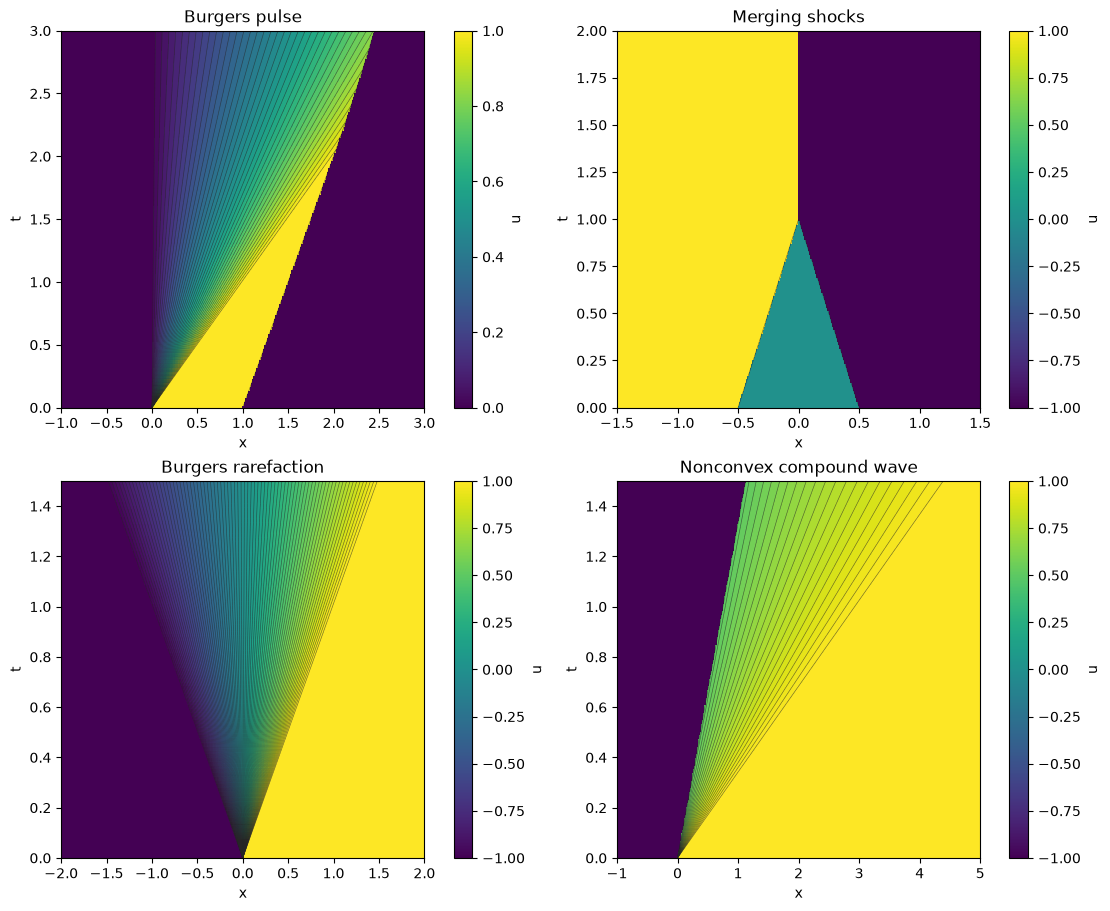

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
for ax, (name, h) in zip(axes.flat, experiments.items()):
    plot_spacetime(h, ax=ax)
    ax.set_title(name)
plt.show()


## Interactive explorer
Choose an experiment, then move the time slider or press Play. Colours keep the same meaning throughout each experiment.


In [6]:
selector = widgets.Dropdown(options=list(experiments), description="Experiment",
                           style={"description_width": "initial"}, layout=widgets.Layout(width="400px"))
viewer_box = widgets.VBox()
def select_experiment(change=None):
    for old in viewer_box.children:
        old.close()
    viewer_box.children = (dashboard(experiments[selector.value]),)
selector.observe(select_experiment, names="value")
select_experiment()
display(widgets.VBox([selector, viewer_box]))


## Profile snapshots
Change the experiment name or snapshot fractions and rerun this cell. Profiles use actual front locations at the nearest saved times; each title gives the time displayed.


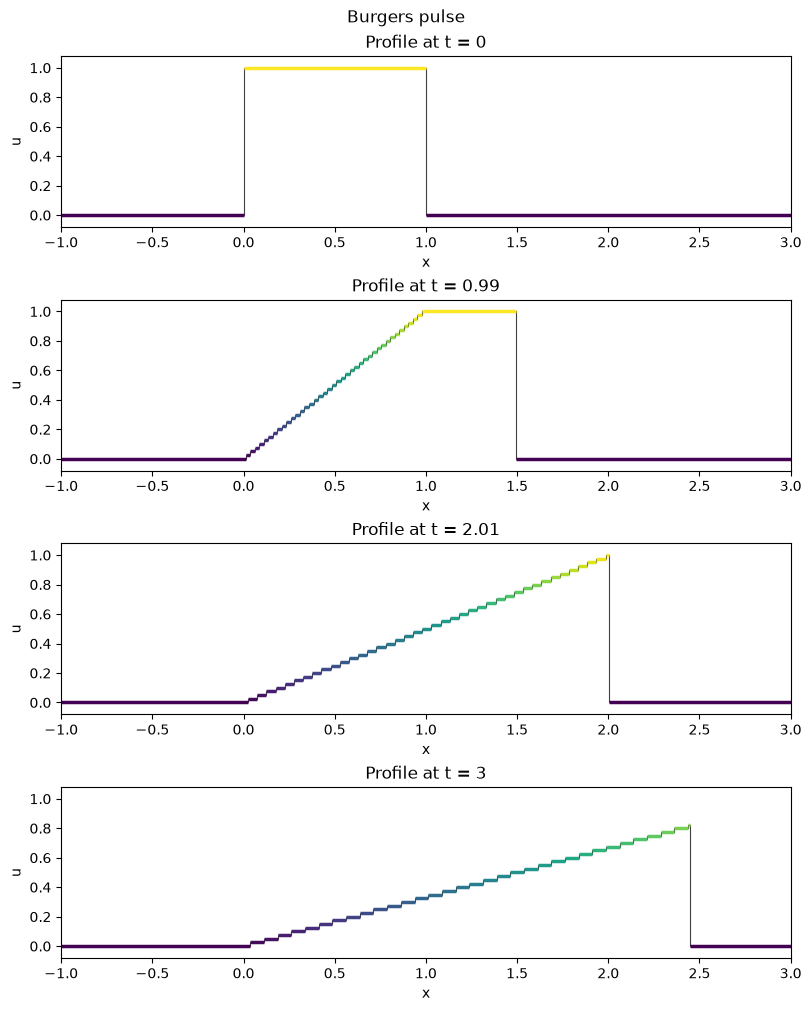

In [7]:
experiment_name = "Burgers pulse"
snapshot_fractions = [0.0, 1/3, 2/3, 1.0]
h = experiments[experiment_name]
if not len(snapshot_fractions) or not np.isfinite(snapshot_fractions).all() \
        or np.any((np.asarray(snapshot_fractions) < 0) | (np.asarray(snapshot_fractions) > 1)):
    raise ValueError("Snapshot fractions must lie in [0,1]")
fig, axes = plt.subplots(len(snapshot_fractions), 1, figsize=(8, 2.5*len(snapshot_fractions)),
                         constrained_layout=True, squeeze=False)
for ax, fraction in zip(axes[:, 0], snapshot_fractions):
    k = int(np.argmin(abs(h.times - fraction*h.times[-1])))
    plot_profile(h, k, ax=ax)
fig.suptitle(experiment_name)
plt.show()


## Export the selected experiment
Exports the currently selected dropdown experiment. Repeating the cell replaces the named files.


In [8]:
h = experiments[selector.value]
output_dir = Path("front_tracking_exports")
output_dir.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
plot_spacetime(h, ax=ax)
ax.set_title(selector.value)
fig.savefig(output_dir / "demo_spacetime.png", dpi=180)
plt.close(fig)
np.savez_compressed(output_dir / "demo_solution.npz", x=h.x, times=h.times, u=h.values,
                    segments=np.asarray(h.segments).reshape(-1, 4))
print("Exports:", output_dir)


Exports: front_tracking_exports


For your own flux, states, snapshot times and observation window, open **01_front_tracking_playground.ipynb**. These are scalar homogeneous Cauchy experiments, not simulations of systems or imposed boundaries.
